# Main Procedure for Data Preparation and Cleaning

## Dependancies

In [1]:
import pandas as pd
from PIL import Image 
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

In [2]:
full_data = pd.read_excel('./data/20260316_Fish_Data.xlsx', sheet_name='Fish')

## Create Drainage Area to Waterbody Mapping Dataset
Since the NHDES assemblage data does not contain the drainage area of each location, utilize the USGS watershed data based on each unqiue_id of each collection location for watershed data. Save shape file data to a csv with new column for area by sq miles. 

In [ ]:
gdf = gpd.read_file("./src/data/Shapefiles/All_Watersheds_wJoin.zip")

# Project to UTM zone 19N (covers New Hampshire/Vermont area) for accurate area calculation
projected = gdf.to_crs(epsg=32619)

# Calculate area in square miles (1 sq meter = 3.86102e-7 sq miles)
SQ_M_TO_SQ_MI = 3.86102e-7
projected["area (sq mi)"] = projected.geometry.area * SQ_M_TO_SQ_MI

# Copy the new column back to the original GDF (drop geometry for CSV export)
gdf["area (sq mi)"] = projected["area (sq mi)"]

output_df = gdf.drop(columns="geometry")
output_df.to_csv("./src/data/watersheds_with_area_based-on-shp.csv", index=False)

print(f"Saved {len(output_df)} records to watersheds_with_area_based-on-shp.csv")
print(output_df[["Name", "Unique_ID", "area (sq mi)"]].head(10))

# Extract NLCD Landuse Data
We want to determine what extent of human interaction should disqualify collection sites from inclusion. We do this by using NLCD land use data for each year. 

In [1]:
import rasterio
from rasterio.mask import mask as rio_mask
import geopandas as gpd
import pandas as pd
import numpy as np

# --- NLCD developed-class imperviousness weights (midpoints of each class range) ---
IMPERV_WEIGHTS = {
    21: 0.10,   # Developed, Open Space (0–20%)
    22: 0.35,   # Developed, Low Intensity (20–49%)
    23: 0.65,   # Developed, Medium Intensity (50–79%)
    24: 0.90,   # Developed, High Intensity (80–100%)
    31: 0.10,   # Barren Land (assumed 0–20% impervious)
}

# --- Load data ---
site_data = pd.read_csv('./data/site_species_presence.csv')
site_data.drop(columns=['pct_imperviousness'], inplace=True, errors='ignore')  # Remove if exists

# Load watershed polygons and reproject to NLCD CRS (Albers Equal Area)
watersheds = gpd.read_file('./data/Shapefiles/All_Watersheds_wJoin.zip')
with rasterio.open('./data/NLCD tiffs/Annual_NLCD_LndCov_2002_CU_C1V1.tiff') as ref:
    nlcd_crs = ref.crs
watersheds = watersheds.to_crs(nlcd_crs)
watersheds['Unique_ID'] = watersheds['Unique_ID'].str.strip()

# Build a lookup: Unique_ID -> watershed geometry
ws_lookup = watersheds.set_index('Unique_ID')['geometry'].to_dict()

# Extract year from each Unique_ID
site_data['year'] = site_data['Unique_ID'].str.extract(r'_(\d{4})$')[0].astype(int)

# --- Calculate % imperviousness per site ---
results = {}
tiff_cache = {}

for _, row in site_data.iterrows():
    uid = row['Unique_ID']
    year = row['year']

    geom = ws_lookup.get(uid.strip())
    if geom is None:
        results[uid] = np.nan
        continue

    if year not in tiff_cache:
        path = f'./data/NLCD tiffs/Annual_NLCD_LndCov_{year}_CU_C1V1.tiff'
        tiff_cache[year] = rasterio.open(path)
    src = tiff_cache[year]

    try:
        clipped, _ = rio_mask(src, [geom], crop=True, nodata=0)
        pixels = clipped[0]  # single band
        valid = pixels[pixels != 0]

        if len(valid) == 0:
            results[uid] = np.nan
            continue

        # Weighted imperviousness: sum of (weight * count) / total valid pixels
        weighted_sum = sum(
            IMPERV_WEIGHTS.get(int(cls), 0.0) * np.sum(valid == cls)
            for cls in np.unique(valid)
        )
        results[uid] = (weighted_sum / len(valid)) * 100  # as percentage
    except Exception:
        results[uid] = np.nan

# Close cached tiff handles
for src in tiff_cache.values():
    src.close()

# --- Add to dataframe and save ---
site_data['pct_imperviousness'] = site_data['Unique_ID'].map(results)
site_data.drop(columns='year', inplace=True)

site_data.to_csv('./data/site_species_presence.csv', index=False)
print(f"Added pct_imperviousness to {site_data['pct_imperviousness'].notna().sum()} of {len(site_data)} sites")
print(site_data['pct_imperviousness'].describe())
print(site_data[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'pct_imperviousness']].head(10))

Added pct_imperviousness to 570 of 577 sites
count    570.000000
mean       1.771923
std        3.877179
min        0.000000
25%        0.300225
50%        0.682475
75%        1.405974
max       43.552032
Name: pct_imperviousness, dtype: float64
            Unique_ID   latitude  longitude  watershed_area  \
0    00-MIP_5_27_2021  43.001751 -71.661510       41.388147   
1    00-MIP_8_22_2024  43.001751 -71.661510       41.388147   
2   00B-PDB_9_14_2023  43.867904 -71.398396        8.083094   
3   00C-BRK_7_13_2004  44.305489 -71.756152        5.624183   
4    00C-BRK_8_2_2022  44.305511 -71.756144        5.624183   
5   00C-OVB_7_22_2024  44.047100 -72.064410       40.795329   
6   00C-WKR_6_22_2005  42.710469 -71.772352        5.274119   
7   00D-BRB_6_30_2022  42.789300 -72.438700       14.641938   
8  00D-CORS_8_23_2019  44.801143 -71.193237        6.218613   
9   00E-PGS_7_22_2021  43.896393 -71.293472       12.025154   

   pct_imperviousness  
0            1.664875  
1           

In [16]:

# Build species presence/absence CSV
import pandas as pd
import re
import io

fish = pd.read_excel('./data/20260316_Fish_Data.xlsx', sheet_name='Fish')

# Some waterbody names contain commas (e.g. "Gale River, NB, US of Dam") and are
# quoted, but with trailing spaces before the closing delimiter — fix before parsing.
with open('./data/watersheds_with_area_based-on-shp.csv', encoding='utf-8') as f:
    raw = f.read()
fixed = re.sub(r'"([^"]*)"\s+,', r'"\1",', raw)
watersheds = pd.read_csv(io.StringIO(fixed))

# Per (Unique_ID, species): sum total individuals collected
totals = (
    fish.groupby(['Unique_ID', 'Abbreviation'])['Individuals']
    .sum()
    .reset_index()
)

# Compute cw_ind: 1 if sum of EBT + SS individuals at site >= 30, else 0
cw = (
    totals[totals['Abbreviation'].isin(['EBT', 'SS'])]
    .groupby('Unique_ID')['Individuals']
    .sum()
    .reset_index()
)
cw['cw_ind'] = (cw['Individuals'] >= 30).astype(int)
cw = cw[['Unique_ID', 'cw_ind']]

# Pivot: rows = Unique_ID, columns = species abbreviations (excluding EBT and SS)
pivot = totals.pivot_table(index='Unique_ID', columns='Abbreviation', values='Individuals', aggfunc='sum', fill_value=0)
pivot = pivot.drop(columns=['NO FISH', 'EBT', 'SS'], errors='ignore')

# Encode presence (>=30) as 1, absence (<30) as 0
species_cols = pivot.columns.tolist()
pivot[species_cols] = (pivot[species_cols] >= 30).astype(int)
pivot = pivot.reset_index()

# Lat/lon: use first recorded value per Unique_ID from fish data
coords = (
    fish.dropna(subset=['Lat_Dec_USGS', 'Long_Dec_USGS'])
    .groupby('Unique_ID')[['Lat_Dec_USGS', 'Long_Dec_USGS']]
    .first()
    .reset_index()
    .rename(columns={'Lat_Dec_USGS': 'latitude', 'Long_Dec_USGS': 'longitude'})
)

# Watershed area: pull from shapefile-derived CSV
area = watersheds[['Unique_ID', 'area (sq mi)']].rename(columns={'area (sq mi)': 'watershed_area'})
area['Unique_ID'] = area['Unique_ID'].str.strip()

# Merge everything together
result = pivot.merge(coords, on='Unique_ID', how='left')
result = result.merge(area, on='Unique_ID', how='left')
result = result.merge(cw, on='Unique_ID', how='left')
result['cw_ind'] = result['cw_ind'].fillna(0).astype(int)

# Reorder columns: unique_id, latitude, longitude, watershed_area, cw_ind, then remaining species
col_order = ['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind'] + species_cols
result = result[col_order]

result.to_csv('./data/site_species_presence.csv', index=False)
print(f"Saved {len(result)} sites x {len(species_cols)} species to site_species_presence.csv")
result.head()


Saved 577 sites x 51 species to site_species_presence.csv


,Unique_ID,latitude,longitude,watershed_area,cw_ind,ABL,AE,ATS,BBH,BC,...,RT,SD,SL,SMB,STK,STS,TD,WP,YBH,YP
0,00-MIP_5_27_2021,43.001751,-71.661510,41.388147,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,00-MIP_8_22_2024,43.001751,-71.661510,41.388147,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,00B-PDB_9_14_2023,43.867904,-71.398396,8.083094,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,00C-BRK_7_13_2004,44.305489,-71.756152,5.624183,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,00C-BRK_8_2_2022,44.305511,-71.756144,5.624183,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = pd.read_csv('./data/site_species_presence.csv')

total_sites = data.shape[0]

data['watershed_area'].describe()

count    570.000000
mean      18.889754
std       24.414243
min        0.136051
25%        4.513247
50%        9.869965
75%       23.327325
max      256.023883
Name: watershed_area, dtype: float64

**Visualizations of what fish appear alongside SS and EBT**

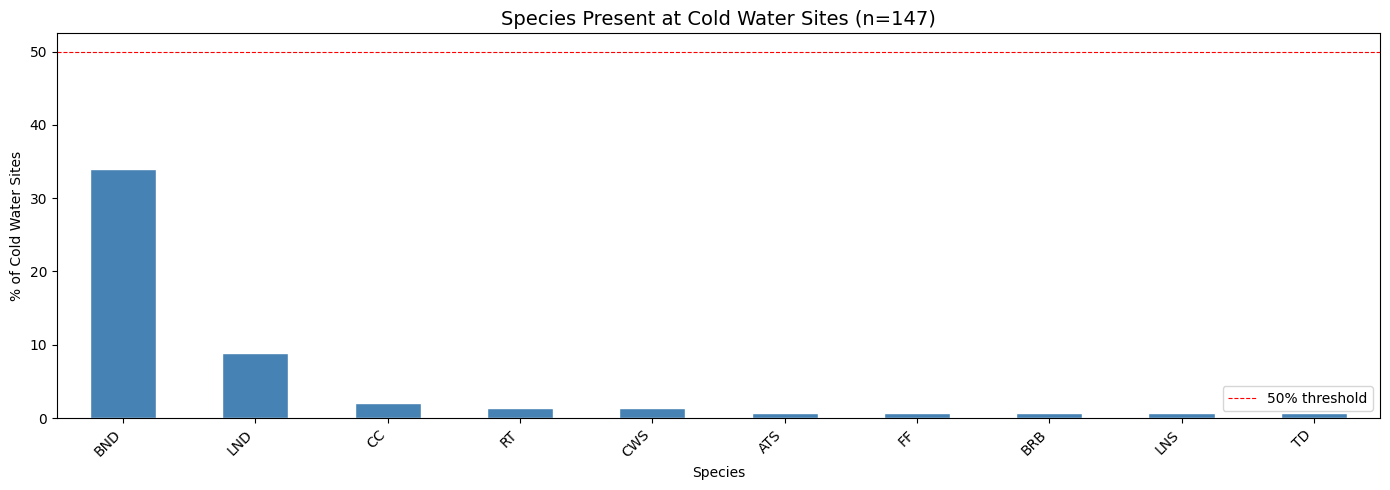

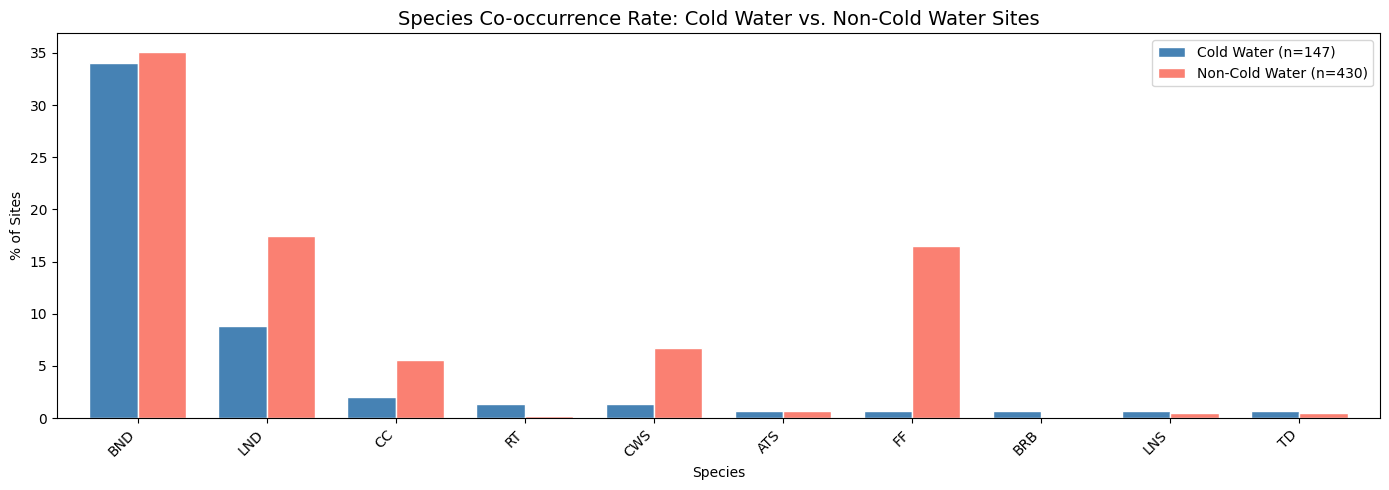

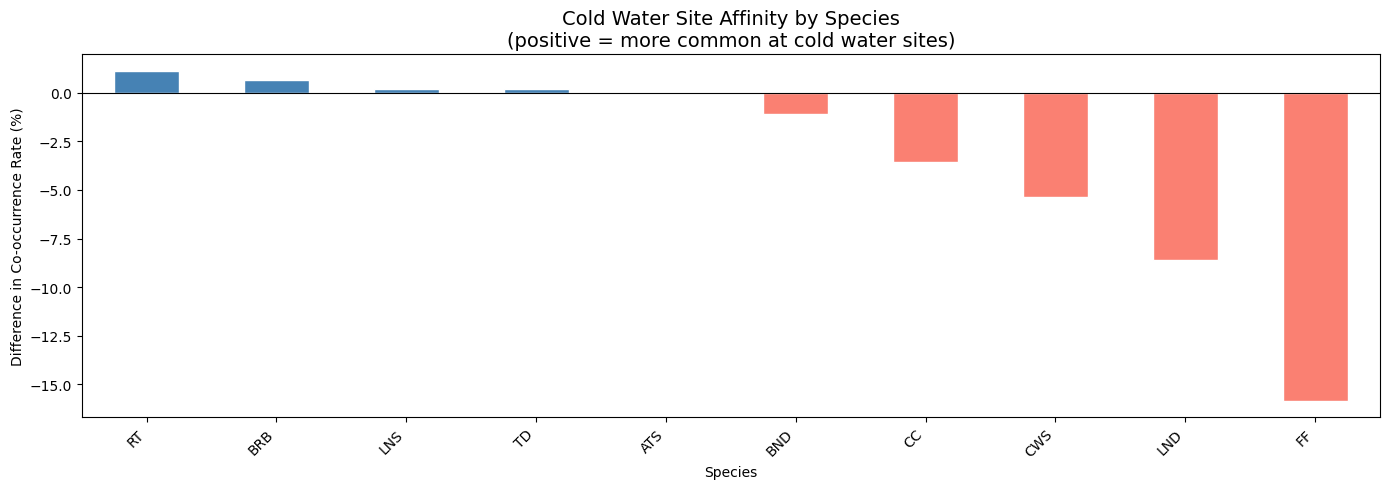

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

presence_data = pd.read_csv('./data/site_species_presence.csv')

species_cols = [c for c in presence_data.columns if c not in ['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind']]

cw_sites = presence_data[presence_data['cw_ind'] == 1]
non_cw_sites = presence_data[presence_data['cw_ind'] == 0]
cw_count = len(cw_sites)
non_cw_count = len(non_cw_sites)

cw_rate = cw_sites[species_cols].sum() / cw_count * 100
non_cw_rate = non_cw_sites[species_cols].sum() / non_cw_count * 100

# Only include species present at at least one cold water site
cw_rate = cw_rate[cw_rate > 0].sort_values(ascending=False)

# --- Plot 1: Co-occurrence rate at cold water sites ---
fig, ax = plt.subplots(figsize=(14, 5))
cw_rate.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Species Present at Cold Water Sites (n={cw_count})', fontsize=14)
ax.set_xlabel('Species')
ax.set_ylabel('% of Cold Water Sites')
ax.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot 2: Cold water vs. non-cold water co-occurrence rates ---
compare = pd.DataFrame({
    f'Cold Water (n={cw_count})': cw_sites[species_cols].sum() / cw_count * 100,
    f'Non-Cold Water (n={non_cw_count})': non_cw_sites[species_cols].sum() / non_cw_count * 100,
}).loc[cw_rate.index]

fig, ax = plt.subplots(figsize=(14, 5))
compare.plot(kind='bar', ax=ax, color=['steelblue', 'salmon'], edgecolor='white', width=0.75)
ax.set_title('Species Co-occurrence Rate: Cold Water vs. Non-Cold Water Sites', fontsize=14)
ax.set_xlabel('Species')
ax.set_ylabel('% of Sites')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot 3: Difference in co-occurrence (cold water affinity) ---
diff = (compare.iloc[:, 0] - compare.iloc[:, 1]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['steelblue' if v >= 0 else 'salmon' for v in diff]
diff.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Cold Water Site Affinity by Species\n(positive = more common at cold water sites)', fontsize=14)
ax.set_xlabel('Species')
ax.set_ylabel('Difference in Co-occurrence Rate (%)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()